In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Notebook to explore the data

In [3]:
images_df = pd.read_csv("../data/images.csv")
styles_df = pd.read_csv("../data/styles.csv")   

In [4]:
images_df.head(5)

,filename,link
0,15970.jpg,http://assets.myntassets.com/v1/images/style/p...
1,39386.jpg,http://assets.myntassets.com/v1/images/style/p...
2,59263.jpg,http://assets.myntassets.com/v1/images/style/p...
3,21379.jpg,http://assets.myntassets.com/v1/images/style/p...
4,53759.jpg,http://assets.myntassets.com/v1/images/style/p...


In [5]:
styles_df.head(5)

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


The id's column in styles df match up with filename of images df so we can merge the two dfs. First we need to do some cleaning on the filename so we can merge.

In [6]:
images_df["file_id"] = images_df["filename"].apply(lambda x: int(x.split(".")[0]))

images_df.head(5)

,filename,link,file_id
0,15970.jpg,http://assets.myntassets.com/v1/images/style/p...,15970
1,39386.jpg,http://assets.myntassets.com/v1/images/style/p...,39386
2,59263.jpg,http://assets.myntassets.com/v1/images/style/p...,59263
3,21379.jpg,http://assets.myntassets.com/v1/images/style/p...,21379
4,53759.jpg,http://assets.myntassets.com/v1/images/style/p...,53759


In [7]:
combined_df = pd.merge(images_df, styles_df, left_on="file_id", right_on="id")

combined_df.head(5)

,filename,link,file_id,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970.jpg,http://assets.myntassets.com/v1/images/style/p...,15970,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386.jpg,http://assets.myntassets.com/v1/images/style/p...,39386,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263.jpg,http://assets.myntassets.com/v1/images/style/p...,59263,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379.jpg,http://assets.myntassets.com/v1/images/style/p...,21379,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759.jpg,http://assets.myntassets.com/v1/images/style/p...,53759,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [8]:
combined_df["subCategory"].unique()

array(['Topwear', 'Bottomwear', 'Watches', 'Socks', 'Shoes', 'Belts',
       'Flip Flops', 'Bags', 'Innerwear', 'Sandal', 'Shoe Accessories',
       'Fragrance', 'Jewellery', 'Lips', 'Saree', 'Eyewear', 'Nails',
       'Scarves', 'Dress', 'Loungewear and Nightwear', 'Wallets',
       'Apparel Set', 'Headwear', 'Mufflers', 'Skin Care', 'Makeup',
       'Free Gifts', 'Ties', 'Accessories', 'Skin', 'Beauty Accessories',
       'Water Bottle', 'Eyes', 'Bath and Body', 'Gloves',
       'Sports Accessories', 'Cufflinks', 'Sports Equipment', 'Stoles',
       'Hair', 'Perfumes', 'Home Furnishing', 'Umbrellas', 'Wristbands',
       'Vouchers'], dtype=object)

There are a lot of classes of clothing that we do not need. Lets keep only the rows that correspond to the following list:

- shirt
- pants
- shoes
- jacket
- dress
- skirt

In [9]:
combined_df = combined_df[combined_df['subCategory'].isin(["Topwear", "Bottomwear", 
                                                           "Shoes", "Dress"])]

print(combined_df.size)
combined_df["subCategory"].unique()

336973


array(['Topwear', 'Bottomwear', 'Shoes', 'Dress'], dtype=object)

In [14]:
combined_df["usage"].unique()

array(['Casual', 'Ethnic', 'Formal', 'Sports', nan, 'Smart Casual',
       'Party', 'Travel'], dtype=object)

There are also a lot of styles of clothing that we don not need to look at so lets keep only the rows with the following styles:

- Casual
- Formal
- Sports
- Party
- Travel

In [15]:
combined_df['usage'] = combined_df['usage'].replace('Smart Casual', "Casual")
combined_df = combined_df[combined_df['usage'].isin(["Casual", "Formal", 
                                                           "Sports", "Party", "Travel"])]

print(combined_df.size)
combined_df["usage"].unique()

304785


array(['Casual', 'Formal', 'Sports', 'Party', 'Travel'], dtype=object)

In [16]:
combined_df["articleType"].unique()

array(['Shirts', 'Jeans', 'Track Pants', 'Tshirts', 'Casual Shoes',
       'Tops', 'Sweatshirts', 'Formal Shoes', 'Flats', 'Waistcoat',
       'Sports Shoes', 'Shorts', 'Heels', 'Dresses', 'Skirts', 'Blazers',
       'Shrug', 'Trousers', 'Capris', 'Tunics', 'Jackets', 'Sweaters',
       'Tracksuits', 'Swimwear', 'Leggings', 'Jumpsuit', 'Suspenders',
       'Stockings', 'Kurtas', 'Tights', 'Jeggings', 'Rompers', 'Sandals',
       'Rain Jacket', 'Belts', 'Kurtis', 'Suits'], dtype=object)

Right now the topwear category has a lot of variety. It includes both normal tops and also outwear like blazers and waistcoats and jackets. I will split this category into 2, one for just topwear, and one for outerwear.

In [17]:
combined_df[combined_df['subCategory']=="Topwear"]['articleType'].unique()

array(['Shirts', 'Tshirts', 'Tops', 'Sweatshirts', 'Waistcoat', 'Blazers',
       'Shrug', 'Tunics', 'Jackets', 'Sweaters', 'Suspenders', 'Kurtas',
       'Rompers', 'Dresses', 'Rain Jacket', 'Belts', 'Kurtis', 'Suits'],
      dtype=object)

In [41]:
# Update subCategory for Dresses because some dresses had a subcategory of Topwear.
combined_df['subCategory'] = combined_df.apply(lambda row: "Dress" if row['articleType'] == "Dresses" else row['subCategory'], axis=1)

# remove Kurtas, Kurtis, Belts, and Suspenders
combined_df = combined_df[~combined_df['articleType'].isin(['Kurtas', 'Kurtis', 'Belts', 'Suspenders'])]
combined_df[combined_df['subCategory']=="Topwear"]['articleType'].unique()

tops = ["Shirts", "Tshirts", "Tops", "Sweaters", "Sweatshirts", "Tunics", "Waistcoat", "Rompers"]
outer = ["Jackets", "Blazers", "Rain Jacket", "Shrug", "Suits"]

def change_topwear_category(row):
    if row['subCategory'] == "Topwear":
        if row['articleType'] in tops:
            return "Tops"
        elif row['articleType'] in outer:
            return "Outerwear"
    return row['subCategory']

combined_df['subCategory'] = combined_df.apply(change_topwear_category, axis=1)

combined_df["subCategory"].unique()

array(['Tops', 'Bottomwear', 'Shoes', 'Dress', 'Outerwear'], dtype=object)

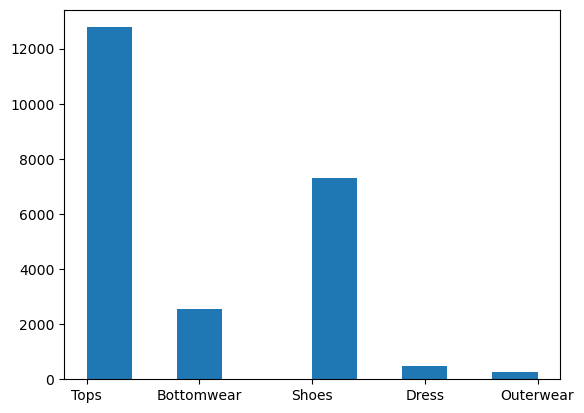

In [42]:
plt.hist(combined_df["subCategory"])
plt.show()

## Final Deliverables

### Finalized category list
'Topwear', 'Bottomwear', 'Shoes', 'Dress'

These include shirts, pants, shoes, jackets, dresses, skirts

### Finalized genre list

'Casual', 'Formal', 'Sports', 'Party', 'Travel'

### JSON/schema for wardrobe items
The JSON schema in the google doc is perfect

{

  "item_id": "001",

  "image_path": "uploads/blue_shirt.jpg",

  "category": "top",

  "subcategory": "button_down",

  "color": "blue",

  "style_tags": ["business_casual", "minimal"],

  "season": "all_season"
  
}

